In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Total Columns and Rows:", df.shape)

Total Columns and Rows: (9994, 21)


There are 9,994 rows and 21 columns in this dataset. These numbers are expected since we're looking at the multi-year retail business data - enough records to identify meaningful trends across regions and categories.

In [5]:
print("Data Types of Each Column:\n", df.dtypes)

Data Types of Each Column:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


There are some inconsistent data types in this dataset. 'Order Date' and 'Ship Date' should have datetime data type. This needs to be fixed before any time-based analysis.

In [6]:
print("Null Values in the Dataset:\n", df.isnull().sum())
print("Duplicate Rows in the Dataset:", df.duplicated().sum())

Null Values in the Dataset:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate Rows in the Dataset: 0


No null or duplicate rows were found in the dataset. The dataset appears structurally complete, though outliers in Sales and Profit will be worth checking in the summary statistics.

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

In [9]:
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe()

,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


Profit ranges from around -$6,600 to $8,400, confirming there are loss-making orders in the data. The average discount is 15%, with some orders discounted as high as 80%. This level of discounting may be contributing to the negative profits and is worth investigating in Q2.

### Q1: Which regions and product categories are most and least profitable?

Without knowing this, the business risks investing equally in all areas and miss the opportunity to gain more profit from the most profitable ones.

In [ ]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

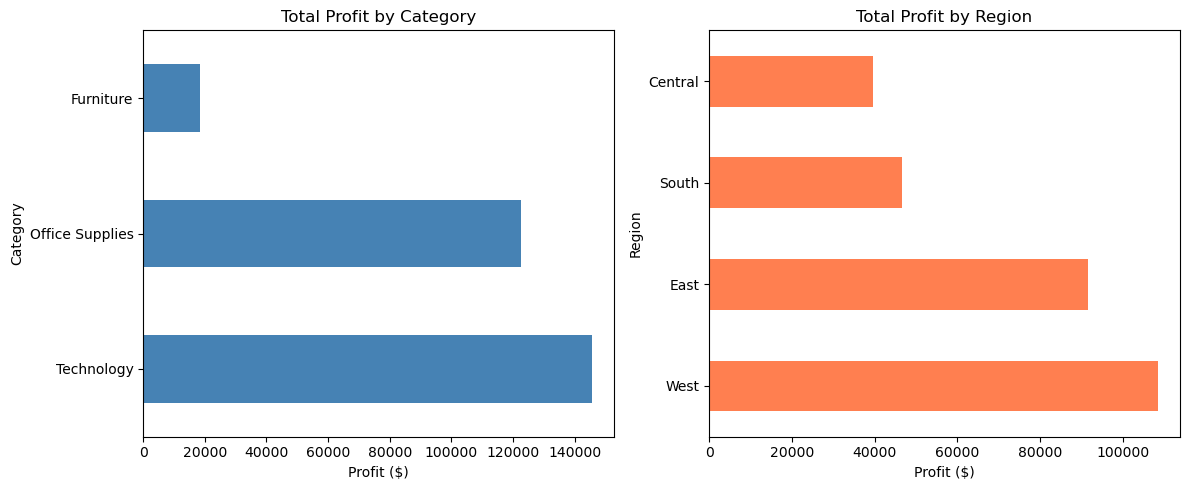

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

profit_by_category.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Profit by Category')
axes[0].set_xlabel('Profit ($)')

profit_by_region.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Total Profit by Region')
axes[1].set_xlabel('Profit ($)')

plt.tight_layout()
plt.show()

The West region generates the highest total profit with $108k, and Central region generates the lowest total profit with $39k. Furniture generated $18k versus Technology's $145k - roughly 12% of Technology's profit. The Furniture category's low profit warrants a deeper investigation in the following questions. Without knowing this, the business risks investing equally in all areas, missing the opportunity to invest more in profitable categories and regions.

### Q2: Are discounts helping or hurting the business?

If discounts aren't driving enough extra sales to cover the reduced price, the business would need to reconsider the discount and rethinking its pricing strategy.

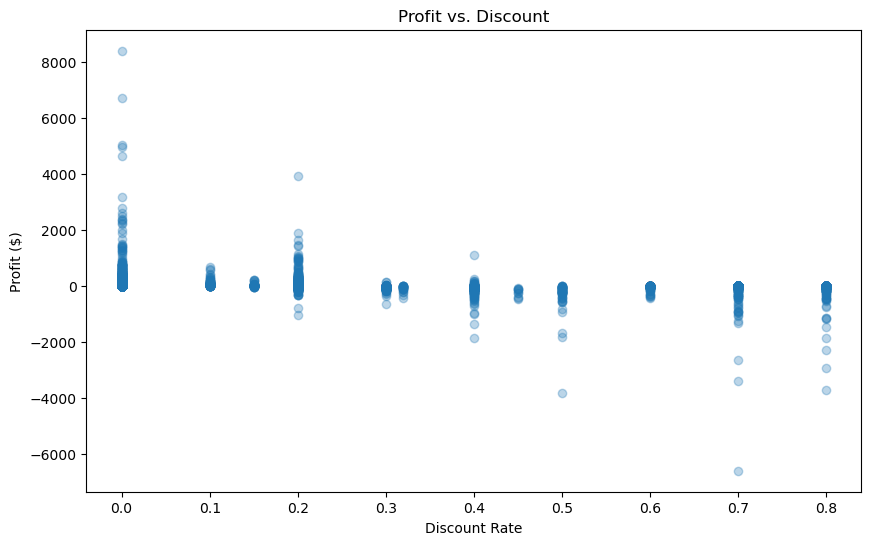

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3)
plt.title('Profit vs. Discount')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.show()

In [19]:
print("Total orders:", len(df))
print("Orders with discount above 40%:", (df['Discount'] > 0.4).sum())
print("Total loss from those orders:", df[df['Discount'] > 0.4]['Profit'].sum())

Total orders: 9994
Orders with discount above 40%: 933
Total loss from those orders: -99558.59049999999


The business received most profits when there is no discount applied, with a highest profit of $8k. When discounts are applied, the most profit is received at 20%  with a highest of $4k. The trend is going downward - the bigger the discount, the lower the profit. Orders with discounts above 40% account for 933 orders - roughly 9% of total orders - generating a combined loss of $99k. This suggests the business should review discounts above 40%, as they appear to be generating losses rather than profit.

### Q3: Which customer segments drive the most revenue vs. profit?

Without knowing this, the business risks focusing its efforts on segments that appear valuable but are not actually profitable for the business.

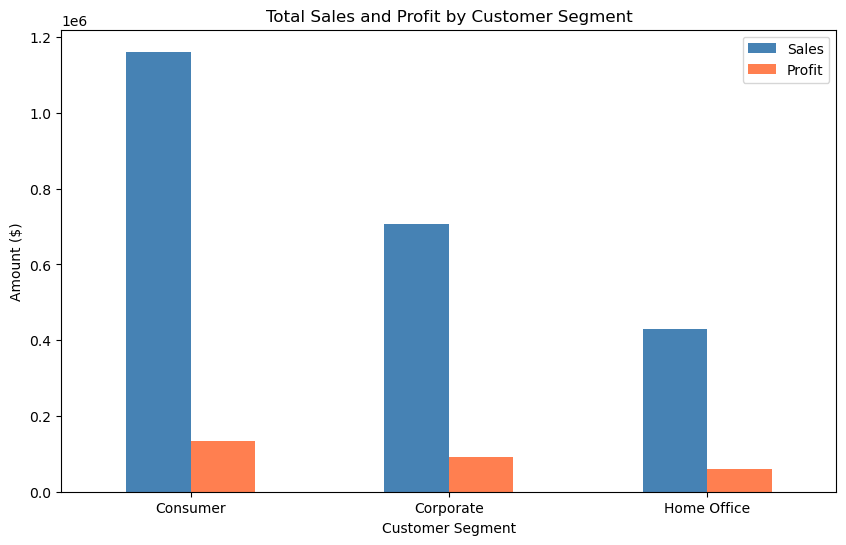

In [14]:
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum()

segment_analysis.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Total Sales and Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

In [28]:
print("Total profit:", df['Profit'].sum())
profit_by_segment = df.groupby('Segment')['Profit'].sum()
print("Total profit generated by Consumer segment:", profit_by_segment['Consumer'])

print("Total sales:", df['Sales'].sum())
sales_by_segment = df.groupby('Segment')['Sales'].sum()
print("Total sales generated by Consumer segment:", sales_by_segment['Consumer'])

Total profit: 286397.0217
Total profit generated by Consumer segment: 134119.2092
Total sales: 2297200.8603000003
Total sales generated by Consumer segment: 1161401.345


Consumer is the segment that drives the most revenue and profit, contributing $134k in profit - roughly 46% of total profit - and $1.16M in sales, which is approximately half of total revenue. All three segments have a roughly similar gap between revenue and profit. The profit bars are small compared to sales across all segment which means that the profit margin is relatively thin but heavy discounting - as seen in Q2 - can wipe the margin out quickly.

### Q4: Are there any products the company should consider dropping?

Without knowing this, the business risks continuing to spend time, money, and resources on low-performing products, when those could be used for more profitable ones.

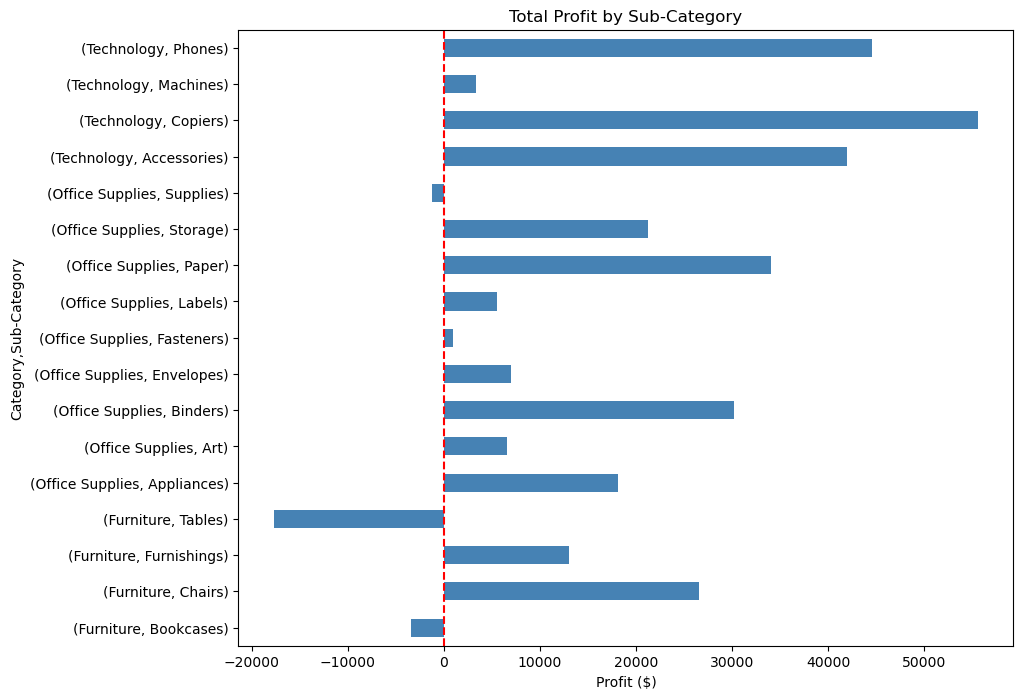

In [15]:
profit_by_subcat = df.groupby(['Category', 'Sub-Category'])['Profit'].sum()

profit_by_subcat.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.show()

Supplies, tables, and bookcases are generating losses for the business. Two out of three are in the Furniture category, which explains the finding from Q1 that Furniture is the least profitable category overall. It is worth investigating further in Phase 3 whether these losses are driven by heavy discounting or whether these sub-categories are inherently unprofitable.

### Q5: What's the sales trend over time — are we growing?

Without knowing this, the business risks going forward blind, failing to catch a decline early enough to adjust their sales strategy and reallocate resources.

In [30]:
sales_trend_year = df.groupby('Order Year')['Sales'].sum()
sales_trend_month = df.groupby('Order Month')['Sales'].sum()
profit_trend_year = df.groupby('Order Year')['Profit'].sum()
profit_trend_month = df.groupby('Order Month')['Profit'].sum()

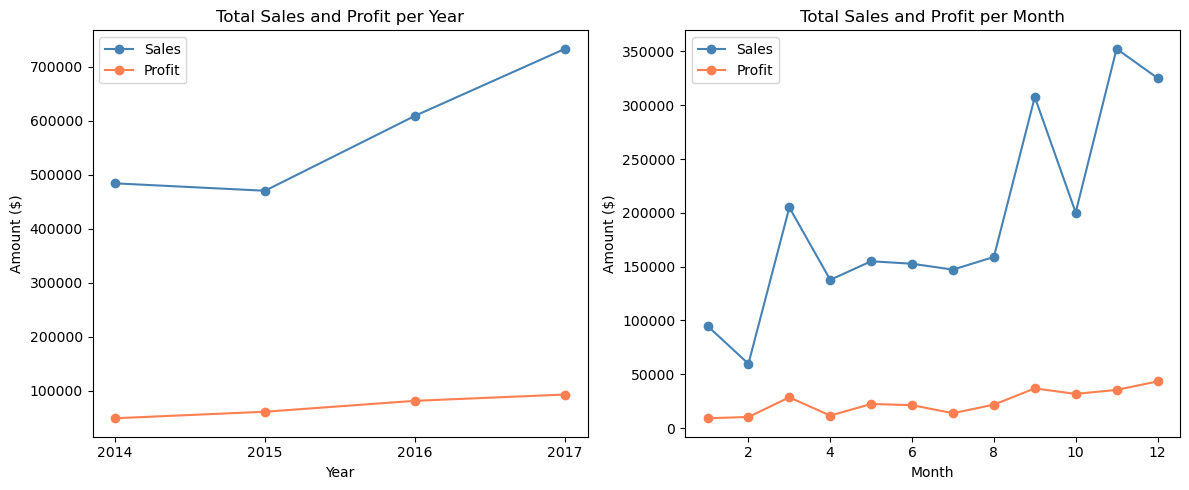

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Yearly trends
axes[0].plot(sales_trend_year.index, sales_trend_year.values, marker='o', color='steelblue', label='Sales')
axes[0].plot(profit_trend_year.index, profit_trend_year.values, marker='o', color='coral', label='Profit')
axes[0].set_title('Total Sales and Profit per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Amount ($)')
axes[0].set_xticks(sales_trend_year.index)
axes[0].legend()

# Monthly trends
axes[1].plot(sales_trend_month.index, sales_trend_month.values, marker='o', color='steelblue', label='Sales')
axes[1].plot(profit_trend_month.index, profit_trend_month.values, marker='o', color='coral', label='Profit')
axes[1].set_title('Total Sales and Profit per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [54]:
print("Total Sales vs. Profit per Year:\n", df.groupby('Order Year')[['Sales', 'Profit']].sum())
print("Total Sales vs. Profit per Month:\n", df.groupby('Order Month')[['Sales', 'Profit']].sum())

Total Sales vs. Profit per Year:
                   Sales      Profit
Order Year                         
2014        484247.4981  49543.9741
2015        470532.5090  61618.6037
2016        609205.5980  81795.1743
2017        733215.2552  93439.2696
Total Sales vs. Profit per Month:
                    Sales      Profit
Order Month                         
1             94924.8356   9134.4461
2             59751.2514  10294.6107
3            205005.4888  28594.6872
4            137762.1286  11587.4363
5            155028.8117  22411.3078
6            152718.6793  21285.7954
7            147238.0970  13832.6648
8            159044.0630  21776.9384
9            307649.9457  36857.4753
10           200322.9847  31784.0413
11           352461.0710  35468.4265
12           325293.5035  43369.1919


The sales and profit are growing every year with the highest sales at 2017 with $733k and the lowest sales at 2015 with below $500, the highest profit is also at 2017 with $93k. The sales and profit also seem to be growing every month with some ups and downs. The highest sales is at November with around $352k and the lowest is at February with around $50k, the highest profit is at December with $43k. This shows that the business is growing over time. However, growing sales does not guarantee the business is healthy - as seen in Q1 and Q2, profit is uneven across categories, regions, and discount levels. While both sales and profit grew between 2014 and 2017, profit grew at a slower pace than sales, suggesting the business is generating more revenue but not proportionally more profit - making cost and discount management critical going forward.